# Unmasked Network Linear-Systems Analysis

This notebook extends the Schur/eigenmode analysis with explicit intermediate steps.

It assumes your original `mij_matrix.csv` has:

\[
\text{rows}=\text{outgoing/source nodes}, \qquad \text{columns}=\text{receiver/target nodes}.
\]

The notebook converts that file into the standard column-vector state convention:

\[
x_{t+1}=Mx_t,\qquad M_{ij}=\text{effect of source }j\text{ on receiver }i.
\]

Therefore:

\[
M=\texttt{df\_source\_receiver.to\_numpy().T}.
\]

The analyses below are:

1. **Structural path analysis** using the matrix power series \(M, M^2, M^3,\ldots\).
2. **Controllability Gramian analysis** for state diffusion.
3. **Frequency response analysis** using

\[
G(s)=C(sI-A)^{-1}B.
\]

Most reusable logic lives in `network_linear_systems_tools_script.py`.

## Notebook role in the analysis sequence

**Role:** Linear-systems companion analysis.

**Inputs:**
- `matrices/mij_matrix.csv` or root-level `mij_matrix.csv`, depending on the notebook control setting.

**Outputs:**
- No required downstream files in the base notebook; results are displayed inline.

**What this notebook adds:**
- Provides a systems-control view of the same directed network.
- Computes matrix-power paths, controllability Gramians, and frequency response.
- Serves as a broader validation layer for the Schur-mode propagation story.


## 0. Notebook Controls

Change these settings before running the notebook.

The default analysis preserves the original weight scale. You can set `NORMALIZATION = "spectral_radius"` if you want equal-gain analysis.

In [1]:
from pathlib import Path

CSV_PATH = Path("mij_matrix.csv")

# Matrix normalization:
#   "none"            -> preserve absolute connectivity scale
#   "column_l1"       -> normalize each source column after orientation correction
#   "spectral_radius" -> scale M so rho(M)=TARGET_SPECTRAL_RADIUS
NORMALIZATION = "none"
TARGET_SPECTRAL_RADIUS = 1.0

# Matrix power/path analysis
MAX_PATH_LENGTH = 6
PATH_ALPHA = 1.0
TOP_N_PRINT = 12

# Discrete-time finite-horizon controllability Gramian
GRAMIAN_HORIZON = 25

# Inputs and outputs:
#   None means all nodes.
#   Or use labels, e.g. DRIVER_NODES = ["EC LII Stellate", "CA3 Pyramidal"]
DRIVER_NODES = None
OUTPUT_NODES = None

# Continuous-time frequency response.
# A = M - shift*I is used by default so that transfer-function analysis is stable.
CONTINUOUS_SHIFT_MARGIN = 0.25
FREQ_MIN = 1e-3
FREQ_MAX = 1e2
FREQ_POINTS = 250

print("Controls loaded.")
print(f"CSV_PATH: {CSV_PATH}")
print(f"NORMALIZATION: {NORMALIZATION}")
print(f"MAX_PATH_LENGTH: {MAX_PATH_LENGTH}")
print(f"GRAMIAN_HORIZON: {GRAMIAN_HORIZON}")

Controls loaded.
CSV_PATH: mij_matrix.csv
NORMALIZATION: none
MAX_PATH_LENGTH: 6
GRAMIAN_HORIZON: 25


## 1. Imports and External Utility Module

The companion file `network_linear_systems_tools_script.py` contains reusable functions for:

- loading and orienting the matrix,
- computing matrix powers,
- extracting top source→receiver path entries,
- controllability Gramians,
- stable continuous-time conversion,
- transfer functions and frequency responses.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import linalg

# Make sure the local module can be imported from the notebook directory.
sys.path.insert(0, str(Path(".").resolve()))

import network_linear_systems_tools_script as nlt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

print("Imported network_linear_systems_tools_script as nlt")
print("Current working directory:", Path.cwd())

Imported network_linear_systems_tools_script as nlt
Current working directory: C:\Users\ranic\Documents\GitHub\schur_decomp


## 2. Load Matrix and Unmask the Orientation Step

The raw CSV is interpreted as source→receiver.

The state matrix is the transpose:

\[
M[\text{receiver},\text{source}]=\text{CSV}[\text{source},\text{receiver}].
\]

In [3]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {CSV_PATH}. Put mij_matrix.csv in the same folder as this notebook, "
        "or update CSV_PATH."
    )

prep = nlt.load_source_receiver_csv(
    CSV_PATH,
    normalization=NORMALIZATION,
    target_spectral_radius=TARGET_SPECTRAL_RADIUS,
)

M = prep.M
df_source_receiver = prep.df_source_receiver
cell_labels = prep.labels

print("=" * 90)
print("RAW CSV CONVENTION")
print("=" * 90)
print("Rows    = outgoing/source cell types")
print("Columns = receiver/target cell types")
print(f"Raw CSV shape: {df_source_receiver.shape}")
display(df_source_receiver.iloc[:8, :8])

print("\n" + "=" * 90)
print("STATE MATRIX CONVENTION")
print("=" * 90)
print("M[receiver, source] is used in x[t+1] = M @ x[t]")
print(f"M shape: {M.shape}")
print(f"Normalization: {prep.normalization}")
print(f"Notes: {prep.notes}")
print(f"Spectral radius rho(M): {prep.spectral_radius:.6f}")

print("\nTop-left block of oriented M:")
display(pd.DataFrame(M, index=cell_labels, columns=cell_labels).iloc[:8, :8])

RAW CSV CONVENTION
Rows    = outgoing/source cell types
Columns = receiver/target cell types
Raw CSV shape: (85, 85)


,CA1 Axo Axonic,CA1 Back Projection,CA1 Basket,CA1 Basket CCK+,CA1 Bistratified,CA1 Horizontal Axo Axonic,CA1 Horizontal Basket,CA1 Ivy
CA1 Axo Axonic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CA1 Back Projection,-165.950861,-196.341673,-370.357839,-344.975192,-155.664261,-161.942236,-228.555369,-93.674019
CA1 Basket,-280.028888,0.000000,-655.973659,-512.455720,-301.349364,0.000000,-730.807386,-206.099353
CA1 Basket CCK+,-601.336194,0.000000,-1334.263907,-1112.086946,-744.309499,0.000000,-1523.625908,-482.591255
CA1 Bistratified,-103.530310,-126.408425,-261.897465,-241.226827,-145.310374,-144.761902,-229.278181,-84.889708
CA1 Horizontal Axo Axonic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CA1 Horizontal Basket,-208.721801,0.000000,-483.528099,-418.047381,-334.483781,0.000000,-549.160577,-214.331169
CA1 Ivy,-75.160462,-143.674886,-193.108705,-170.463080,-112.485660,-158.779219,-262.197093,-67.162476



STATE MATRIX CONVENTION
M[receiver, source] is used in x[t+1] = M @ x[t]
M shape: (85, 85)
Normalization: none
Notes: No normalization. Absolute weight scale is preserved.
Spectral radius rho(M): 26213.130121

Top-left block of oriented M:


,CA1 Axo Axonic,CA1 Back Projection,CA1 Basket,CA1 Basket CCK+,CA1 Bistratified,CA1 Horizontal Axo Axonic,CA1 Horizontal Basket,CA1 Ivy
CA1 Axo Axonic,0.0,-165.950861,-280.028888,-601.336194,-103.530310,0.0,-208.721801,-75.160462
CA1 Back Projection,0.0,-196.341673,0.000000,0.000000,-126.408425,0.0,0.000000,-143.674886
CA1 Basket,0.0,-370.357839,-655.973659,-1334.263907,-261.897465,0.0,-483.528099,-193.108705
CA1 Basket CCK+,0.0,-344.975192,-512.455720,-1112.086946,-241.226827,0.0,-418.047381,-170.463080
CA1 Bistratified,0.0,-155.664261,-301.349364,-744.309499,-145.310374,0.0,-334.483781,-112.485660
CA1 Horizontal Axo Axonic,0.0,-161.942236,0.000000,0.000000,-144.761902,0.0,0.000000,-158.779219
CA1 Horizontal Basket,0.0,-228.555369,-730.807386,-1523.625908,-229.278181,0.0,-549.160577,-262.197093
CA1 Ivy,0.0,-93.674019,-206.099353,-482.591255,-84.889708,0.0,-214.331169,-67.162476


## 3. Quick Spectral Diagnostics

These checks clarify whether the discrete-time system is stable and how strong global recurrence is.

For

\[
x_{t+1}=Mx_t,
\]

asymptotic stability requires:

\[
\rho(M)<1.
\]

SPECTRAL DIAGNOSTICS
Spectral radius rho(M): 26213.130121
Discrete-time stable iff rho(M)<1: False
Max real eigenvalue part: 26213.130121
Frobenius norm ||M||_F: 2129668.767780
Spectral norm ||M||_2: 1679573.257106
Rank estimate: 85 / 85


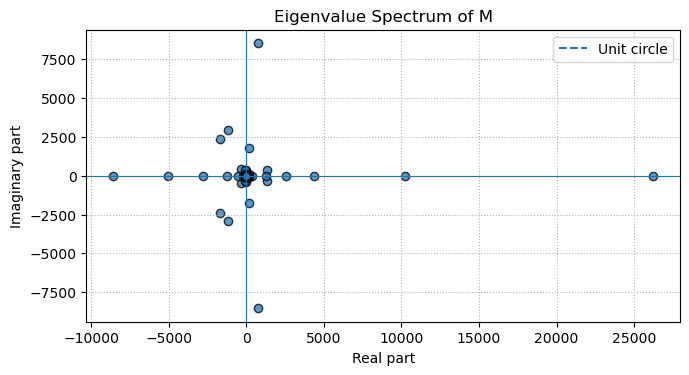

In [4]:
eigvals = np.linalg.eigvals(M)
rho = np.max(np.abs(eigvals))
spectral_abscissa_M = np.max(np.real(eigvals))

print("=" * 90)
print("SPECTRAL DIAGNOSTICS")
print("=" * 90)
print(f"Spectral radius rho(M): {rho:.6f}")
print(f"Discrete-time stable iff rho(M)<1: {rho < 1}")
print(f"Max real eigenvalue part: {spectral_abscissa_M:.6f}")
print(f"Frobenius norm ||M||_F: {np.linalg.norm(M, 'fro'):.6f}")
print(f"Spectral norm ||M||_2: {np.linalg.norm(M, 2):.6f}")
print(f"Rank estimate: {np.linalg.matrix_rank(M)} / {M.shape[0]}")

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(eigvals.real, eigvals.imag, alpha=0.75, edgecolors="black")
theta = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(theta), np.sin(theta), linestyle="--", label="Unit circle")
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)
ax.set_title("Eigenvalue Spectrum of M")
ax.set_xlabel("Real part")
ax.set_ylabel("Imaginary part")
ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle=":")
ax.legend()
plt.tight_layout()
plt.show()

# Part I — Structural Path Analysis: Matrix Power Series

For the oriented matrix \(M\),

\[
(M^k)_{ij}
\]

is the total weighted contribution of all length-\(k\) walks from source node \(j\) to receiver node \(i\).

So:

- \(M\) gives direct one-step paths.
- \(M^2\) gives two-step paths.
- \(M^3\) gives three-step paths.
- \(\sum_{k=1}^{K}\alpha^k M^k\) gives a truncated weighted path reachability matrix.

This section prints the intermediate powers and top source→receiver paths at each length.

MATRIX POWER SERIES SUMMARY
Computed powers: [1, 2, 3, 4, 5, 6]
Cumulative matrix: sum alpha^k M^k, k=1..6
alpha = 1.0


,k,fro_norm,spectral_norm,max_abs_entry,sum_abs_entries
0,1,2.129669e+06,1.679573e+06,1.227403e+06,1.228041e+07
1,2,2.218265e+10,1.835801e+10,9.365968e+09,2.125648e+11
2,3,3.616747e+14,3.323283e+14,2.277840e+14,3.619704e+15
3,4,9.141857e+18,9.041977e+18,5.896299e+18,7.660294e+19
4,5,2.429236e+23,2.424776e+23,1.545537e+23,1.862641e+24
5,6,6.419155e+27,6.417662e+27,4.049208e+27,4.700530e+28


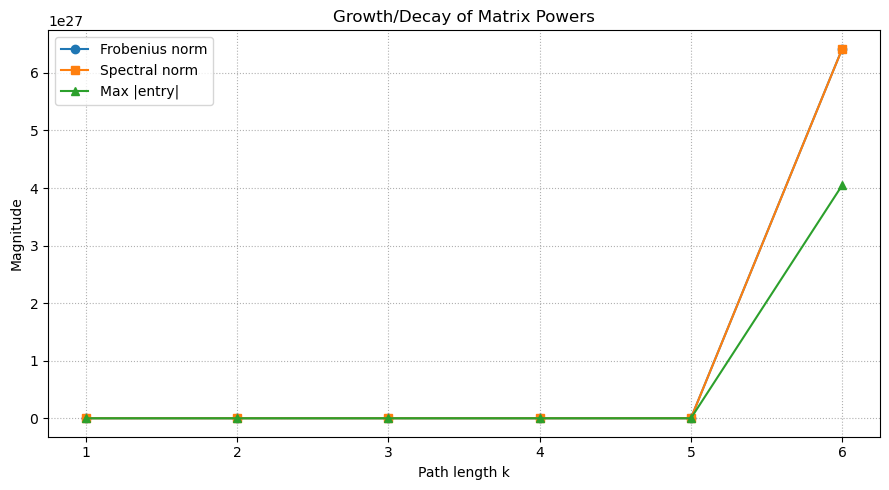

In [5]:
path_results = nlt.matrix_power_series(
    M,
    max_power=MAX_PATH_LENGTH,
    alpha=PATH_ALPHA,
    include_identity=False,
)

powers = path_results["powers"]
cumulative_paths = path_results["cumulative"]
power_norms = path_results["norms"]

print("=" * 90)
print("MATRIX POWER SERIES SUMMARY")
print("=" * 90)
print(f"Computed powers: {list(powers.keys())}")
print(f"Cumulative matrix: sum alpha^k M^k, k=1..{MAX_PATH_LENGTH}")
print(f"alpha = {PATH_ALPHA}")

display(power_norms)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(power_norms["k"], power_norms["fro_norm"], marker="o", label="Frobenius norm")
ax.plot(power_norms["k"], power_norms["spectral_norm"], marker="s", label="Spectral norm")
ax.plot(power_norms["k"], power_norms["max_abs_entry"], marker="^", label="Max |entry|")
ax.set_title("Growth/Decay of Matrix Powers")
ax.set_xlabel("Path length k")
ax.set_ylabel("Magnitude")
ax.grid(True, linestyle=":")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Enumerate Top Paths at Each Length

Each table below lists the strongest aggregate source→receiver contributions in \(M^k\).

Remember:

\[
(M^k)[\text{receiver},\text{source}].
\]

In [6]:
top_paths_by_k = nlt.enumerate_power_top_paths(
    powers,
    labels=cell_labels,
    top_n=TOP_N_PRINT,
    include_diagonal=False,
)

for k, df_top in top_paths_by_k.items():
    print("\n" + "=" * 90)
    print(f"TOP {TOP_N_PRINT} SOURCE→RECEIVER CONTRIBUTIONS FOR PATH LENGTH k={k}")
    print("=" * 90)
    display(df_top[["source", "receiver", "value", "abs_value"]])


TOP 12 SOURCE→RECEIVER CONTRIBUTIONS FOR PATH LENGTH k=1


,source,receiver,value,abs_value
0,CA3 Pyramidal,CA1 Trilaminar,1.227403e+06,1.227403e+06
1,CA3c Pyramidal,CA1 Perforant Path Associated QuadD,9.460521e+05,9.460521e+05
2,CA3c Pyramidal,CA1 Perforant Path Associated,7.737279e+05,7.737279e+05
3,CA3c Pyramidal,CA1 R Receiving Apical Targeting,5.248584e+05,5.248584e+05
4,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,4.081471e+05,4.081471e+05
5,CA3c Pyramidal,CA1 OR LM,3.571523e+05,3.571523e+05
6,CA3c Pyramidal,CA1 Basket,3.525306e+05,3.525306e+05
7,CA3c Pyramidal,CA1 Basket CCK+,3.490040e+05,3.490040e+05
8,CA3c Pyramidal,CA1 LMR,3.430433e+05,3.430433e+05
9,CA3c Pyramidal,CA1 Oriens Alveus,2.710002e+05,2.710002e+05



TOP 12 SOURCE→RECEIVER CONTRIBUTIONS FOR PATH LENGTH k=2


,source,receiver,value,abs_value
0,CA3c Pyramidal,CA1 Trilaminar,9.365968e+09,9.365968e+09
1,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,8.230124e+09,8.230124e+09
2,CA3 Pyramidal,CA1 Perforant Path Associated QuadD,7.105726e+09,7.105726e+09
3,CA3 Pyramidal,CA1 Trilaminar,6.665121e+09,6.665121e+09
4,CA3 Pyramidal,CA1 Perforant Path Associated,5.847016e+09,5.847016e+09
5,MEC LII Stellate,CA1 Trilaminar,5.361812e+09,5.361812e+09
6,CA3 Pyramidal,CA1 R Receiving Apical Targeting,4.422809e+09,4.422809e+09
7,EC LI II Pyramidal Fan,MEC LIII Superficial Multipolar Interneuron,3.208153e+09,3.208153e+09
8,CA3c Pyramidal,CA1 Perforant Path Associated QuadD,3.042926e+09,3.042926e+09
9,CA3 Pyramidal,CA1 OR LM,2.981180e+09,2.981180e+09



TOP 12 SOURCE→RECEIVER CONTRIBUTIONS FOR PATH LENGTH k=3


...

,source,receiver,value,abs_value
0,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,5.896299e+18,5.896299e+18
1,EC LI II Multipolar Pyramidal,CA1 Trilaminar,3.872445e+18,3.872445e+18
2,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated QuadD,2.313988e+18,2.313988e+18
3,EC LI II Pyramidal Fan,MEC LIII Superficial Multipolar Interneuron,1.890018e+18,1.890018e+18
4,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated,1.862477e+18,1.862477e+18
5,EC LI II Multipolar Pyramidal,DG Axo Axonic,1.573445e+18,1.573445e+18
6,EC LI II Pyramidal Fan,CA1 Trilaminar,1.369070e+18,1.369070e+18
7,EC LII III Pyramidal Tripolar,MEC LIII Superficial Multipolar Interneuron,1.130821e+18,1.130821e+18
8,EC LI II Multipolar Pyramidal,DG AIPRIM,1.068607e+18,1.068607e+18
9,EC LI II Multipolar Pyramidal,CA1 R Receiving Apical Targeting,1.001775e+18,1.001775e+18



TOP 12 SOURCE→RECEIVER CONTRIBUTIONS FOR PATH LENGTH k=5


,source,receiver,value,abs_value
0,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,1.545537e+23,1.545537e+23
1,EC LI II Multipolar Pyramidal,CA1 Trilaminar,1.108193e+23,1.108193e+23
2,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated QuadD,6.304650e+22,6.304650e+22
3,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated,4.975157e+22,4.975157e+22
4,EC LI II Pyramidal Fan,MEC LIII Superficial Multipolar Interneuron,4.920294e+22,4.920294e+22
5,EC LI II Multipolar Pyramidal,DG Axo Axonic,4.273605e+22,4.273605e+22
6,EC LI II Pyramidal Fan,CA1 Trilaminar,3.470310e+22,3.470310e+22
7,EC LI II Multipolar Pyramidal,DG AIPRIM,2.992479e+22,2.992479e+22
8,EC LII III Pyramidal Tripolar,MEC LIII Superficial Multipolar Interneuron,2.948515e+22,2.948515e+22
9,EC LI II Multipolar Pyramidal,CA1 R Receiving Apical Targeting,2.795209e+22,2.795209e+22



TOP 12 SOURCE→RECEIVER CONTRIBUTIONS FOR PATH LENGTH k=6


,source,receiver,value,abs_value
0,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,4.049208e+27,4.049208e+27
1,EC LI II Multipolar Pyramidal,CA1 Trilaminar,2.947726e+27,2.947726e+27
2,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated QuadD,1.711030e+27,1.711030e+27
3,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated,1.354005e+27,1.354005e+27
4,EC LI II Pyramidal Fan,MEC LIII Superficial Multipolar Interneuron,1.290041e+27,1.290041e+27
5,EC LI II Multipolar Pyramidal,DG Axo Axonic,1.140632e+27,1.140632e+27
6,EC LI II Pyramidal Fan,CA1 Trilaminar,9.369019e+26,9.369019e+26
7,EC LI II Multipolar Pyramidal,DG AIPRIM,7.979327e+26,7.979327e+26
8,EC LII III Pyramidal Tripolar,MEC LIII Superficial Multipolar Interneuron,7.729010e+26,7.729010e+26
9,EC LI II Multipolar Pyramidal,CA1 R Receiving Apical Targeting,7.688141e+26,7.688141e+26


## 5. Cumulative Path Reachability

This matrix summarizes paths up to the chosen maximum length:

\[
R_K=\sum_{k=1}^{K}\alpha^kM^k.
\]

Large columns indicate strong multi-step outgoing influence.

Large rows indicate strong multi-step incoming reachability.

TOP MULTI-STEP OUTGOING PATH DRIVERS


,cell,outgoing_path_score,incoming_path_score,net_out_minus_in
0,EC LI II Multipolar Pyramidal,2.575115e+28,4.129385e+26,2.533821e+28
1,EC LI II Pyramidal Fan,8.203165e+27,5.163970e+25,8.151525e+27
2,EC LII III Pyramidal Tripolar,4.911459e+27,5.221337e+26,4.389325e+27
3,MEC LII Stellate,1.662919e+27,4.478360e+26,1.215083e+27
4,CA3c Pyramidal,1.330691e+27,3.684700e+25,1.293844e+27
5,CA3 Pyramidal,9.045730e+26,7.671666e+25,8.278563e+26
6,MEC LIII Complex Pyramidal,6.795231e+26,3.152192e+26,3.643039e+26
7,MEC LV Pyramidal,6.112474e+26,1.255335e+26,4.857139e+26
8,LEC LIII Multipolar Principal,6.094797e+26,2.319179e+26,3.775618e+26
9,LEC LIII Complex Pyramidal,3.436219e+26,3.323360e+26,1.128589e+25



TOP MULTI-STEP INCOMING PATH RECEIVERS


,cell,outgoing_path_score,incoming_path_score,net_out_minus_in
20,MEC LIII Superficial Multipolar Interneuron,6.362465e+25,7.103518e+27,-7.039893e+27
55,CA1 Trilaminar,2.686692e+23,5.338820e+27,-5.338552e+27
84,CA1 Perforant Path Associated QuadD,1.937802e+21,3.167468e+27,-3.167466e+27
52,CA1 Perforant Path Associated,3.691045e+23,2.504759e+27,-2.504390e+27
58,DG Axo Axonic,1.369896e+23,2.144326e+27,-2.144189e+27
39,DG AIPRIM,1.946893e+24,1.546752e+27,-1.544805e+27
61,CA1 R Receiving Apical Targeting,1.057717e+23,1.449102e+27,-1.448996e+27
68,CA1 OR LM,5.930628e+22,1.001950e+27,-1.001890e+27
72,CA1 LMR,4.193177e+22,9.592251e+26,-9.591831e+26
36,CA1 Basket CCK+,2.837126e+24,9.132078e+26,-9.103707e+26



TOP 12 ENTRIES IN CUMULATIVE PATH MATRIX


,source,receiver,value,abs_value
0,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,4.049363e+27,4.049363e+27
1,EC LI II Multipolar Pyramidal,CA1 Trilaminar,2.947837e+27,2.947837e+27
2,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated QuadD,1.711093e+27,1.711093e+27
3,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated,1.354055e+27,1.354055e+27
4,EC LI II Pyramidal Fan,MEC LIII Superficial Multipolar Interneuron,1.290091e+27,1.290091e+27
5,EC LI II Multipolar Pyramidal,DG Axo Axonic,1.140675e+27,1.140675e+27
6,EC LI II Pyramidal Fan,CA1 Trilaminar,9.369366e+26,9.369366e+26
7,EC LI II Multipolar Pyramidal,DG AIPRIM,7.979626e+26,7.979626e+26
8,EC LII III Pyramidal Tripolar,MEC LIII Superficial Multipolar Interneuron,7.729305e+26,7.729305e+26
9,EC LI II Multipolar Pyramidal,CA1 R Receiving Apical Targeting,7.688420e+26,7.688420e+26


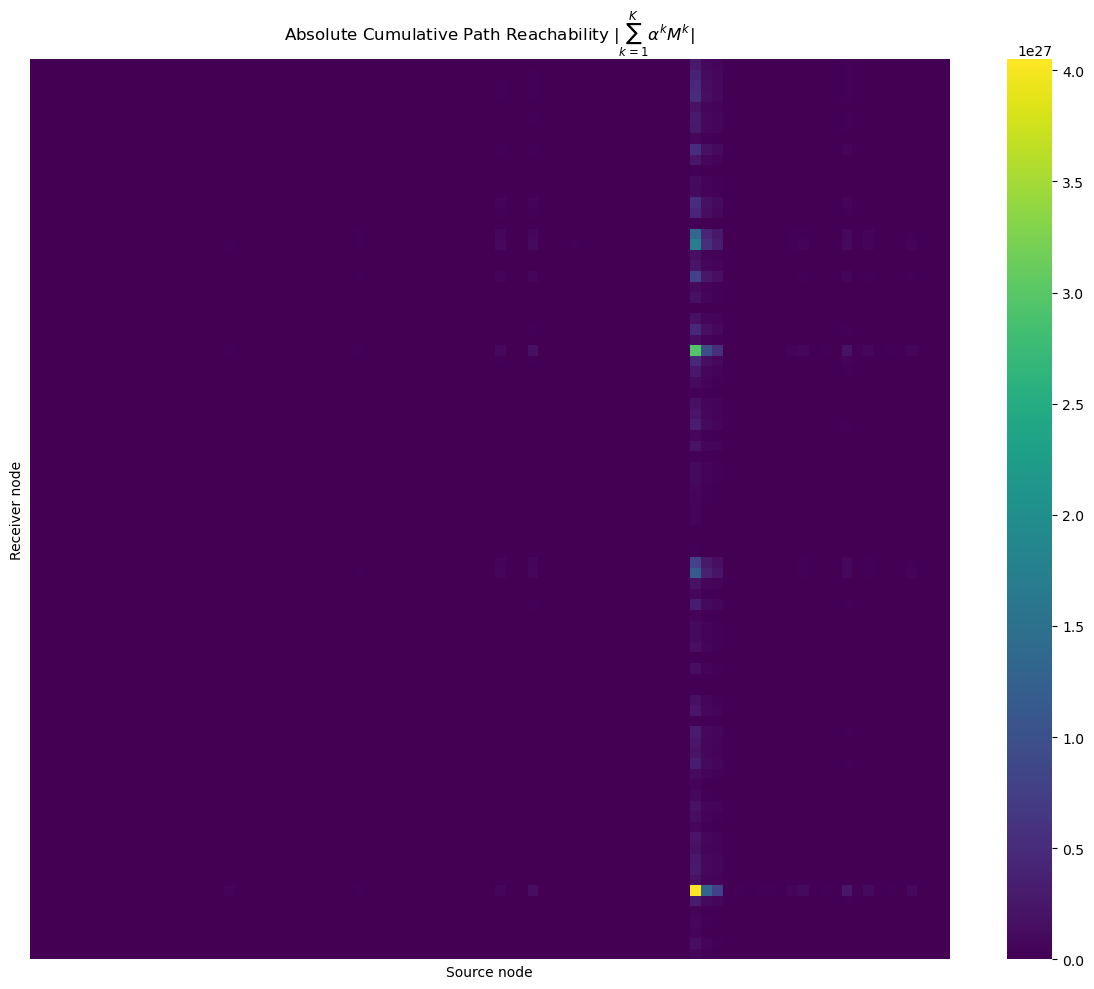

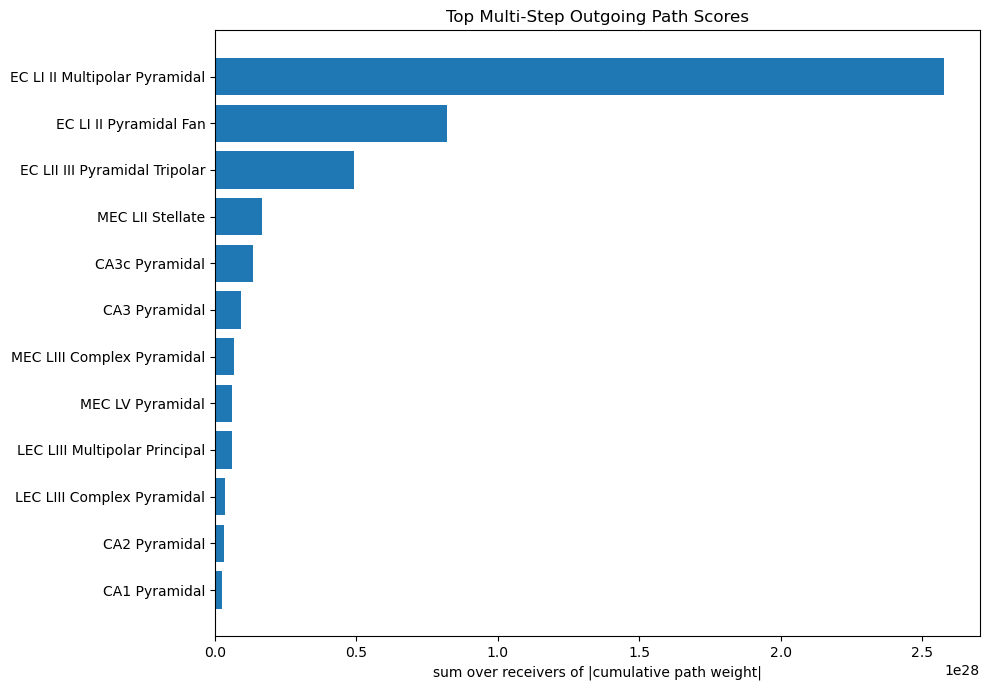

In [7]:
path_scores = nlt.node_path_scores(cumulative_paths, cell_labels)

print("=" * 90)
print("TOP MULTI-STEP OUTGOING PATH DRIVERS")
print("=" * 90)
display(path_scores.head(TOP_N_PRINT))

print("\n" + "=" * 90)
print("TOP MULTI-STEP INCOMING PATH RECEIVERS")
print("=" * 90)
display(path_scores.sort_values("incoming_path_score", ascending=False).head(TOP_N_PRINT))

top_cumulative_entries = nlt.top_entries(
    cumulative_paths,
    labels=cell_labels,
    n=TOP_N_PRINT,
    include_diagonal=False,
)

print("\n" + "=" * 90)
print(f"TOP {TOP_N_PRINT} ENTRIES IN CUMULATIVE PATH MATRIX")
print("=" * 90)
display(top_cumulative_entries[["source", "receiver", "value", "abs_value"]])

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    np.abs(cumulative_paths),
    xticklabels=False,
    yticklabels=False,
    cmap="viridis",
    ax=ax,
)
ax.set_title(r"Absolute Cumulative Path Reachability $|\sum_{k=1}^{K}\alpha^kM^k|$")
ax.set_xlabel("Source node")
ax.set_ylabel("Receiver node")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = path_scores.head(min(TOP_N_PRINT, len(path_scores))).iloc[::-1]
ax.barh(plot_df["cell"], plot_df["outgoing_path_score"])
ax.set_title("Top Multi-Step Outgoing Path Scores")
ax.set_xlabel("sum over receivers of |cumulative path weight|")
plt.tight_layout()
plt.show()

# Part II — Controllability Gramian Analysis: State Diffusion

For the discrete-time system

\[
x_{t+1}=Mx_t+Bu_t,
\]

the finite-horizon controllability Gramian is

\[
W_c(K)=\sum_{k=0}^{K-1}M^kBB^\mathsf{T}(M^\mathsf{T})^k.
\]

Interpretation:

- \(B\) selects which nodes receive external input.
- The diagonal of \(W_c\) measures how much each state coordinate can be energized over the horizon.
- Large off-diagonal entries indicate correlated state diffusion.
- The rank and eigenvalues of \(W_c\) indicate how many state directions are reachable.

This section uses a finite-horizon Gramian, so it works even if \(\rho(M)\geq1\).

In [8]:
B, driver_indices = nlt.make_B(cell_labels, DRIVER_NODES)

driver_labels = [cell_labels[i] for i in driver_indices]
print("=" * 90)
print("INPUT MATRIX B")
print("=" * 90)
print(f"B shape: {B.shape}")
print(f"Number of driver channels: {len(driver_indices)}")
print("First driver labels:")
for label in driver_labels[:min(20, len(driver_labels))]:
    print("  -", label)

gramian_discrete = nlt.controllability_gramian_discrete(
    M,
    B,
    horizon=GRAMIAN_HORIZON,
)

Wc_d = gramian_discrete["Wc"]
gramian_steps = gramian_discrete["increments"]
gramian_scores = nlt.controllability_scores(Wc_d, cell_labels)

print("\n" + "=" * 90)
print("DISCRETE FINITE-HORIZON CONTROLLABILITY GRAMIAN")
print("=" * 90)
print(f"Horizon K: {GRAMIAN_HORIZON}")
print(f"trace(Wc): {gramian_discrete['trace']:.6f}")
print(f"rank estimate: {gramian_discrete['rank_est']} / {M.shape[0]}")
print(f"condition number: {gramian_discrete['condition_number']:.6e}")

print("\nIntermediate growth of Gramian:")
display(gramian_steps.head(15))
display(gramian_steps.tail(5))

print("\nTop controllable/state-diffusion cells by diagonal Wc:")
display(gramian_scores.head(TOP_N_PRINT))

INPUT MATRIX B
B shape: (85, 85)
Number of driver channels: 85
First driver labels:
  - CA1 Axo Axonic
  - CA1 Back Projection
  - CA1 Basket
  - CA1 Basket CCK+
  - CA1 Bistratified
  - CA1 Horizontal Axo Axonic
  - CA1 Horizontal Basket
  - CA1 Ivy
  - CA1 LMR
  - CA1 Neurogliaform
  - CA1 Neurogliaform Projecting
  - CA1 O LM
  - CA1 O LMR
  - CA1 OR LM
  - CA1 Oriens Alveus
  - CA1 Oriens Bistratified
  - CA1 Perforant Path Associated
  - CA1 Perforant Path Associated QuadD
  - CA1 Pyramidal
  - CA1 Quadrilaminar

DISCRETE FINITE-HORIZON CONTROLLABILITY GRAMIAN
Horizon K: 25
trace(Wc): 48649166282062156670852148358274159962024999892378930890869286392981848492674978689706993929856444930718319262991463995575440738996272618477755726263388726538435714000944050633634670844661203733368700085339630338048.000000
rank estimate: 85 / 85
condition number: 2.210617e+23

Intermediate growth of Gramian:


C:\Users\ranic\anaconda3\Lib\site-packages\numpy\linalg\_linalg.py:2790: RuntimeWarning: overflow encountered in dot
  sqnorm = x_real.dot(x_real) + x_imag.dot(x_imag)


,k,term_trace,term_fro_norm,cumulative_trace,cumulative_rank_est
0,0,8.500000e+01,9.219544e+00,8.500000e+01,85
1,1,4.535489e+12,3.160219e+12,4.535489e+12,85
2,2,4.920700e+20,3.529857e+20,4.920700e+20,85
3,3,1.308086e+29,1.119793e+29,1.308086e+29,85
4,4,8.357354e+37,8.176853e+37,8.357354e+37,85
5,5,5.901187e+46,5.879567e+46,5.901187e+46,85
6,6,4.120556e+55,4.118638e+55,4.120556e+55,85
7,7,2.850129e+64,2.849946e+64,2.850129e+64,85
8,8,1.965888e+73,1.965871e+73,1.965888e+73,85
9,9,1.352548e+82,1.352546e+82,1.352548e+82,85


,k,term_trace,term_fro_norm,cumulative_trace,cumulative_rank_est
20,20,2.182350e+179,inf,2.182350e+179,85
21,21,1.499554e+188,inf,1.499554e+188,85
22,22,1.030386e+197,inf,1.030386e+197,85
23,23,7.080071e+205,inf,7.080071e+205,85
24,24,4.864917e+214,inf,4.864917e+214,85



Top controllable/state-diffusion cells by diagonal Wc:


,cell,diagonal_energy,row_abs_spread
0,MEC LIII Superficial Multipolar Interneuron,2.186418e+214,1.408413e+215
1,CA1 Trilaminar,1.181403e+214,1.035291e+215
2,CA1 Perforant Path Associated QuadD,4.019024e+213,6.038425e+214
3,CA1 Perforant Path Associated,2.515758e+213,4.777469e+214
4,DG Axo Axonic,1.832648e+213,4.077584e+214
5,DG AIPRIM,9.229659e+212,2.893718e+214
6,CA1 R Receiving Apical Targeting,8.201542e+212,2.727791e+214
7,CA1 OR LM,3.929207e+212,1.888060e+214
8,CA1 LMR,3.718658e+212,1.836777e+214
9,CA1 Basket CCK+,3.339623e+212,1.740653e+214


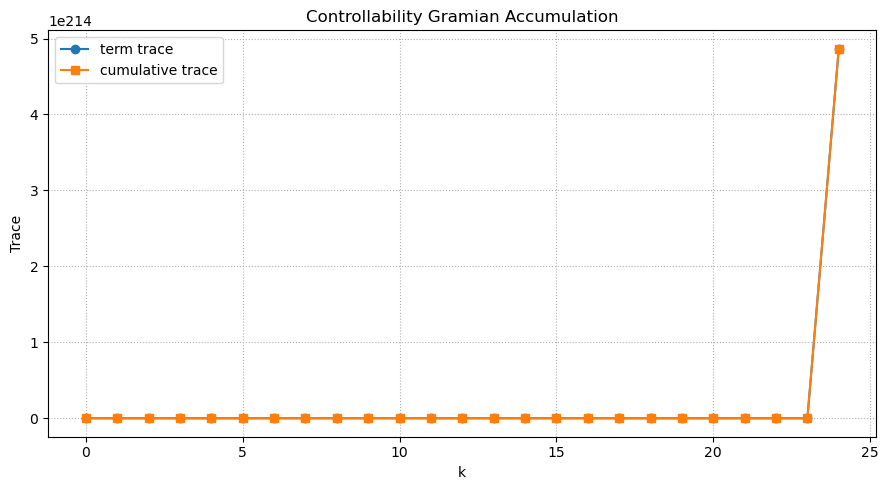

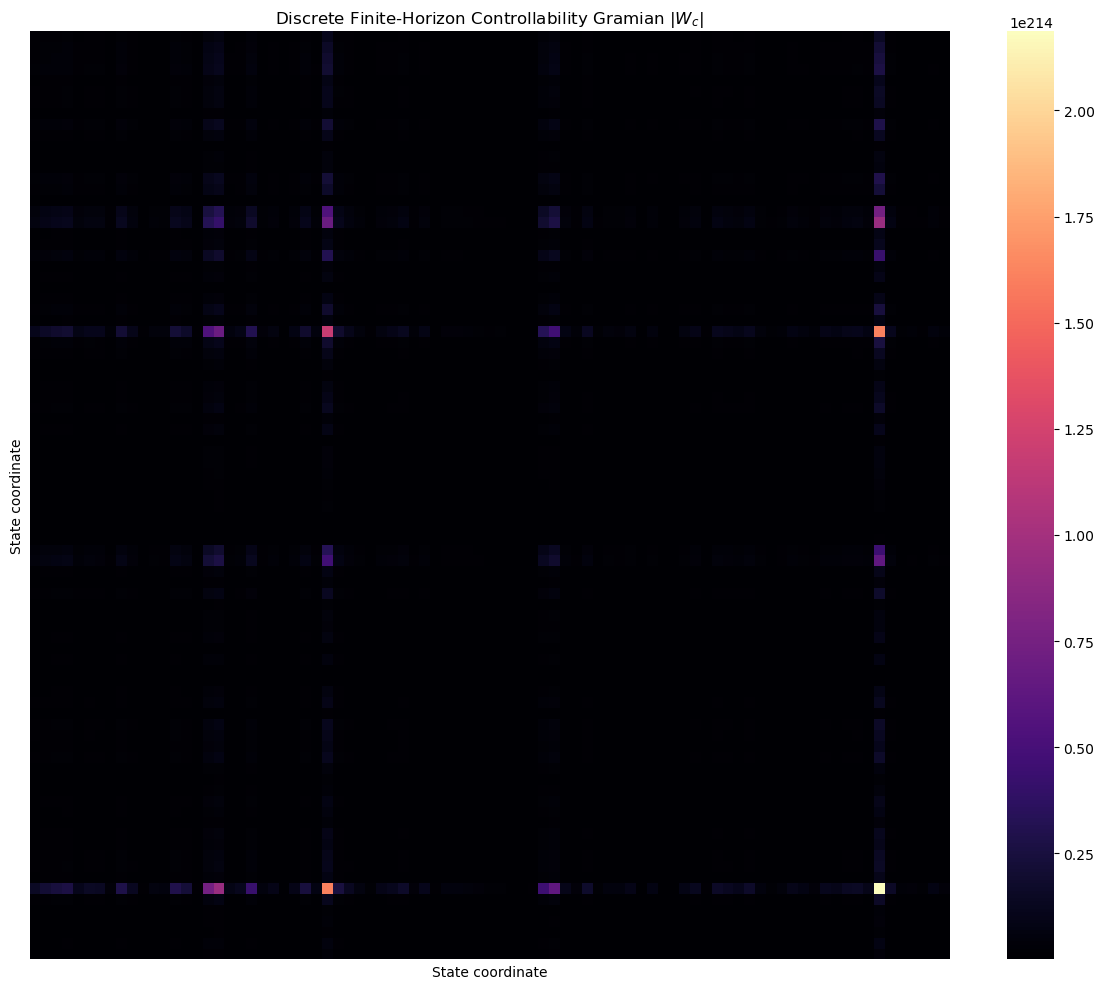

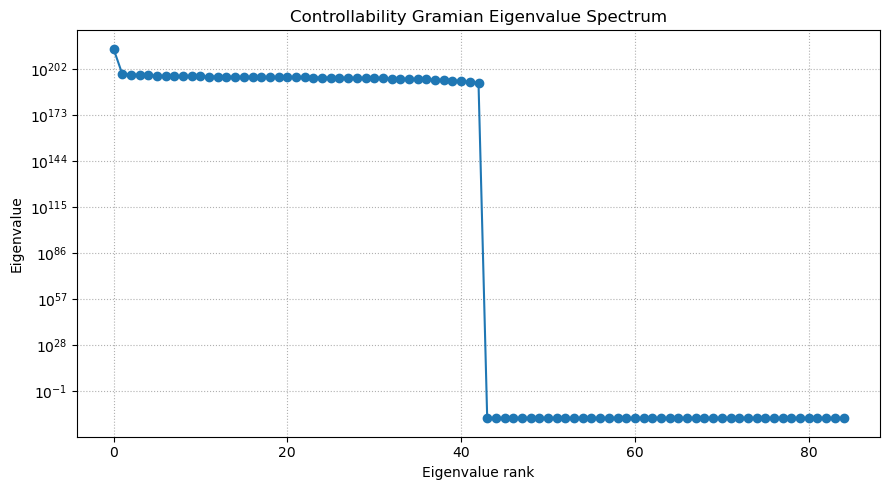

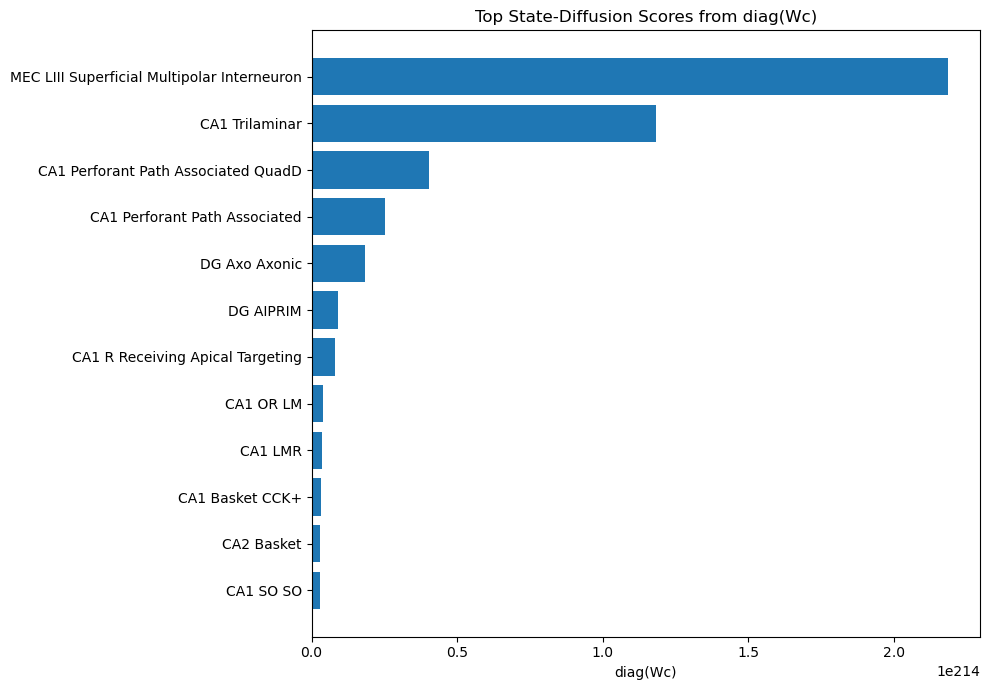

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gramian_steps["k"], gramian_steps["term_trace"], marker="o", label="term trace")
ax.plot(gramian_steps["k"], gramian_steps["cumulative_trace"], marker="s", label="cumulative trace")
ax.set_title("Controllability Gramian Accumulation")
ax.set_xlabel("k")
ax.set_ylabel("Trace")
ax.grid(True, linestyle=":")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    np.abs(Wc_d),
    xticklabels=False,
    yticklabels=False,
    cmap="magma",
    ax=ax,
)
ax.set_title(r"Discrete Finite-Horizon Controllability Gramian $|W_c|$")
ax.set_xlabel("State coordinate")
ax.set_ylabel("State coordinate")
plt.tight_layout()
plt.show()

eig_W = np.maximum(gramian_discrete["eigvals"], 0)
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(np.sort(eig_W)[::-1] + 1e-18, marker="o")
ax.set_title("Controllability Gramian Eigenvalue Spectrum")
ax.set_xlabel("Eigenvalue rank")
ax.set_ylabel("Eigenvalue")
ax.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = gramian_scores.head(min(TOP_N_PRINT, len(gramian_scores))).iloc[::-1]
ax.barh(plot_df["cell"], plot_df["diagonal_energy"])
ax.set_title("Top State-Diffusion Scores from diag(Wc)")
ax.set_xlabel("diag(Wc)")
plt.tight_layout()
plt.show()

## 6. Continuous-Time Gramian Companion

The transfer-function section uses a continuous-time system:

\[
\dot{x}=Ax+Bu,\qquad y=Cx.
\]

Because the raw structural matrix \(M\) is not necessarily a stable continuous-time generator, the notebook constructs

\[
A=M-\gamma I
\]

where \(\gamma\) shifts all eigenvalues left enough to make \(A\) stable.

This does **not** change off-diagonal structural pathways, but it adds uniform leakage/decay.

CONTINUOUS-TIME A MATRIX CONSTRUCTION
A = M - shift * I
spectral abscissa of M: 26213.130121
shift used: 26213.380121
spectral abscissa of A: -0.250000
Continuous-time stable iff max Re(lambda(A)) < 0: True

CONTINUOUS INFINITE-HORIZON CONTROLLABILITY GRAMIAN
trace(Wc): 792.917555
rank estimate: 85 / 85
condition number: 1.053132e+08


,cell,diagonal_energy,row_abs_spread
0,MEC LIII Superficial Multipolar Interneuron,356.325090,2295.259988
1,CA1 Trilaminar,192.560900,1687.309813
2,CA1 Perforant Path Associated QuadD,65.515299,984.194064
3,CA1 Perforant Path Associated,41.009283,778.666244
4,DG Axo Axonic,29.866923,664.524611
5,DG AIPRIM,15.042151,471.593322
6,CA1 R Receiving Apical Targeting,13.371651,444.611268
7,CA1 OR LM,6.406146,307.741772
8,CA1 LMR,6.062031,299.373648
9,CA1 Basket CCK+,5.444483,283.710265


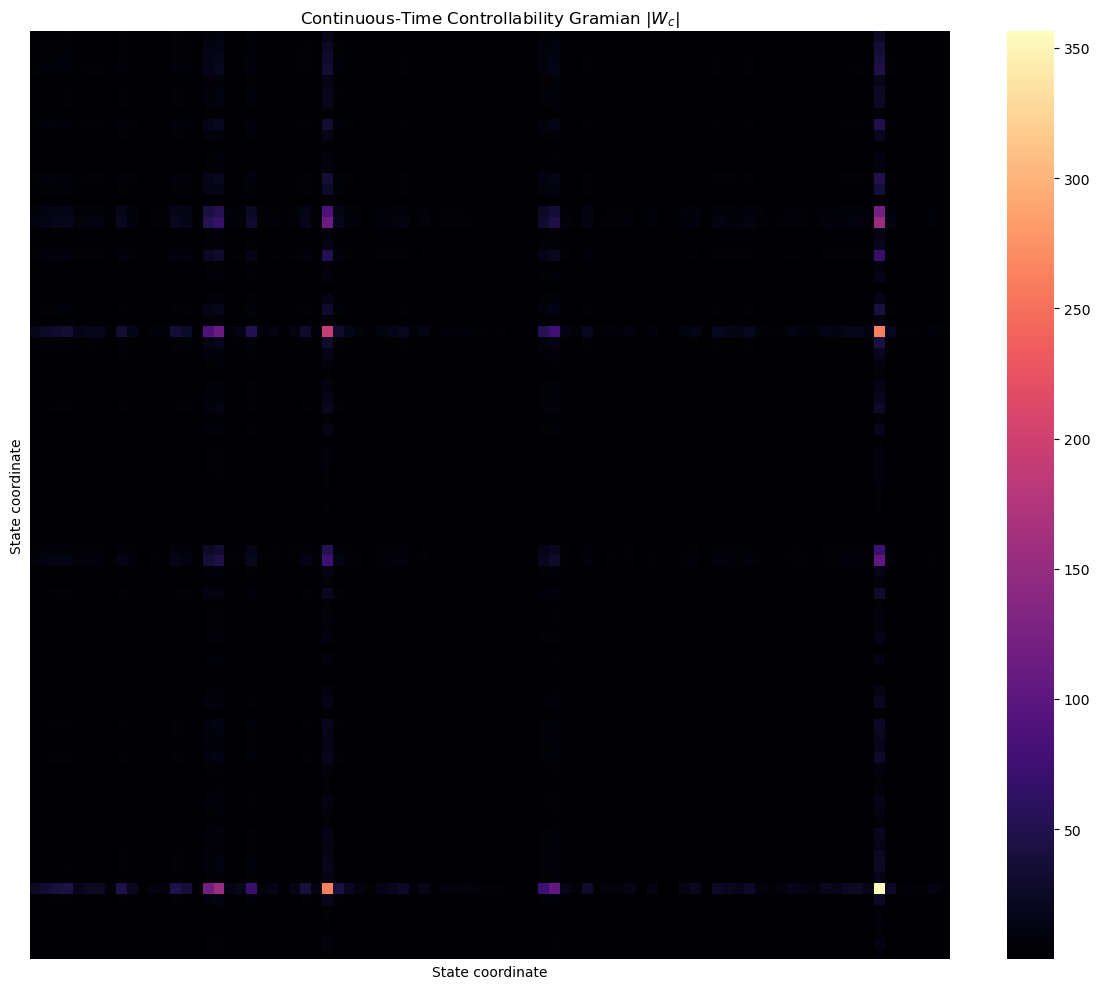

In [10]:
stable_info = nlt.make_stable_continuous_A(
    M,
    margin=CONTINUOUS_SHIFT_MARGIN,
)

A = stable_info["A"]

print("=" * 90)
print("CONTINUOUS-TIME A MATRIX CONSTRUCTION")
print("=" * 90)
print("A = M - shift * I")
print(f"spectral abscissa of M: {stable_info['spectral_abscissa_M']:.6f}")
print(f"shift used: {stable_info['shift']:.6f}")
print(f"spectral abscissa of A: {stable_info['spectral_abscissa_A']:.6f}")
print(f"Continuous-time stable iff max Re(lambda(A)) < 0: {stable_info['spectral_abscissa_A'] < 0}")

gramian_continuous = nlt.controllability_gramian_continuous(A, B)
Wc_c = gramian_continuous["Wc"]
continuous_scores = nlt.controllability_scores(Wc_c, cell_labels)

print("\n" + "=" * 90)
print("CONTINUOUS INFINITE-HORIZON CONTROLLABILITY GRAMIAN")
print("=" * 90)
print(f"trace(Wc): {gramian_continuous['trace']:.6f}")
print(f"rank estimate: {gramian_continuous['rank_est']} / {M.shape[0]}")
print(f"condition number: {gramian_continuous['condition_number']:.6e}")

display(continuous_scores.head(TOP_N_PRINT))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    np.abs(Wc_c),
    xticklabels=False,
    yticklabels=False,
    cmap="magma",
    ax=ax,
)
ax.set_title(r"Continuous-Time Controllability Gramian $|W_c|$")
ax.set_xlabel("State coordinate")
ax.set_ylabel("State coordinate")
plt.tight_layout()
plt.show()

# Part III — Frequency Response

For the continuous-time system

\[
\dot{x}=Ax+Bu,\qquad y=Cx,
\]

the transfer function is

\[
G(s)=C(sI-A)^{-1}B.
\]

At \(s=i\omega\), the response magnitude shows which frequencies are amplified by the network.

This section computes:

\[
\|G(i\omega)\|_2
\]

and prints the strongest input→output channels at the peak frequency.

FREQUENCY RESPONSE SUMMARY
A shape: (85, 85)
B shape: (85, 85)
C shape: (85, 85)
Frequency grid: 0.001 to 100 rad/time, 250 points
Peak ||G(iω)||₂: 79.640285
Peak ω: 0.001


,omega,gain_2norm,gain_fro,min_sigma_iwI_minus_A
0,0.001000,79.640285,79.640285,0.012556
1,0.001047,79.640223,79.640223,0.012556
2,0.001097,79.640155,79.640156,0.012556
247,91.167356,0.218403,0.218428,4.578684
248,95.481598,0.208536,0.208562,4.795330
249,100.000000,0.199115,0.199142,5.022224


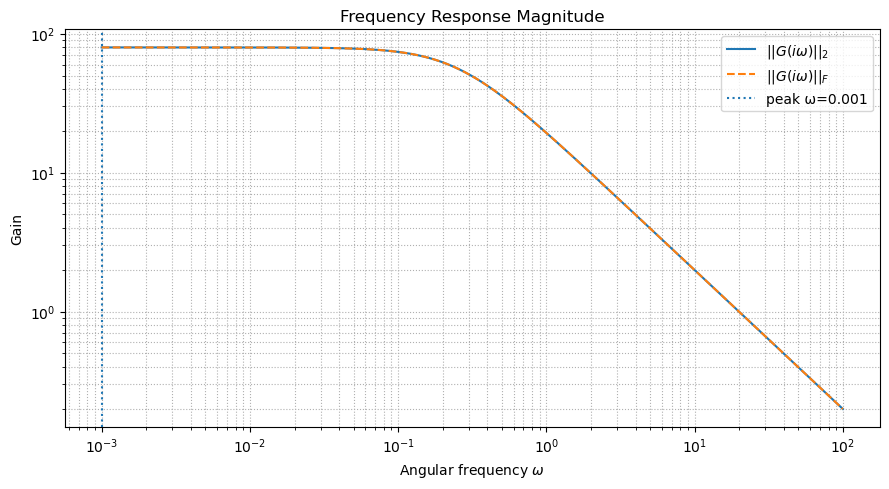

In [11]:
C, output_indices = nlt.make_C(cell_labels, OUTPUT_NODES)

output_labels = [cell_labels[i] for i in output_indices]

omega = np.logspace(np.log10(FREQ_MIN), np.log10(FREQ_MAX), FREQ_POINTS)

freq_results = nlt.frequency_response(A, B, C, omega)
gains_2 = freq_results["gains_2norm"]
gains_fro = freq_results["gains_fro"]

peak_idx = int(np.argmax(gains_2))
peak_omega = float(omega[peak_idx])
peak_gain = float(gains_2[peak_idx])
peak_G = freq_results["responses"][peak_idx]

print("=" * 90)
print("FREQUENCY RESPONSE SUMMARY")
print("=" * 90)
print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")
print(f"C shape: {C.shape}")
print(f"Frequency grid: {FREQ_MIN:g} to {FREQ_MAX:g} rad/time, {FREQ_POINTS} points")
print(f"Peak ||G(iω)||₂: {peak_gain:.6f}")
print(f"Peak ω: {peak_omega:.6g}")

freq_table = pd.DataFrame({
    "omega": omega,
    "gain_2norm": gains_2,
    "gain_fro": gains_fro,
    "min_sigma_iwI_minus_A": freq_results["min_sigma_sI_minus_A"],
})
display(freq_table.iloc[[0, 1, 2, peak_idx, -3, -2, -1]].drop_duplicates())

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(omega, gains_2, label=r"$||G(i\omega)||_2$")
ax.loglog(omega, gains_fro, linestyle="--", label=r"$||G(i\omega)||_F$")
ax.axvline(peak_omega, linestyle=":", label=f"peak ω={peak_omega:.3g}")
ax.set_title("Frequency Response Magnitude")
ax.set_xlabel(r"Angular frequency $\omega$")
ax.set_ylabel("Gain")
ax.grid(True, which="both", linestyle=":")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Top Transfer Channels at Peak Frequency

The transfer matrix has convention:

\[
G[\text{output},\text{input}].
\]

So the table below reads as:

\[
\text{input node} \rightarrow \text{output node}.
\]

TOP 12 TRANSFER CHANNELS AT PEAK FREQUENCY
Peak omega: 0.001


,input,output,magnitude,phase_degrees,value
0,EC LI II Multipolar Pyramidal,MEC LIII Superficial Multipolar Interneuron,49.906605,-0.229184,49.906206- 0.199626j
1,EC LI II Multipolar Pyramidal,CA1 Trilaminar,36.684278,-0.229189,36.683985- 0.146741j
2,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated QuadD,21.396414,-0.229189,21.396242- 0.085588j
3,EC LI II Multipolar Pyramidal,CA1 Perforant Path Associated,16.928393,-0.229189,16.928257- 0.067715j
4,EC LI II Pyramidal Fan,MEC LIII Superficial Multipolar Interneuron,15.899404,-0.229185,15.899276- 0.063598j
5,EC LI II Multipolar Pyramidal,DG Axo Axonic,14.448493,-0.229188,14.448377- 0.057795j
6,EC LI II Pyramidal Fan,CA1 Trilaminar,11.687051,-0.229189,11.686958- 0.046749j
7,EC LI II Multipolar Pyramidal,DG AIPRIM,10.253544,-0.229189,10.253462- 0.041015j
8,EC LI II Multipolar Pyramidal,CA1 R Receiving Apical Targeting,9.665545,-0.229190,9.665468- 0.038663j
9,EC LII III Pyramidal Tripolar,MEC LIII Superficial Multipolar Interneuron,9.525698,-0.229185,9.525622- 0.038103j


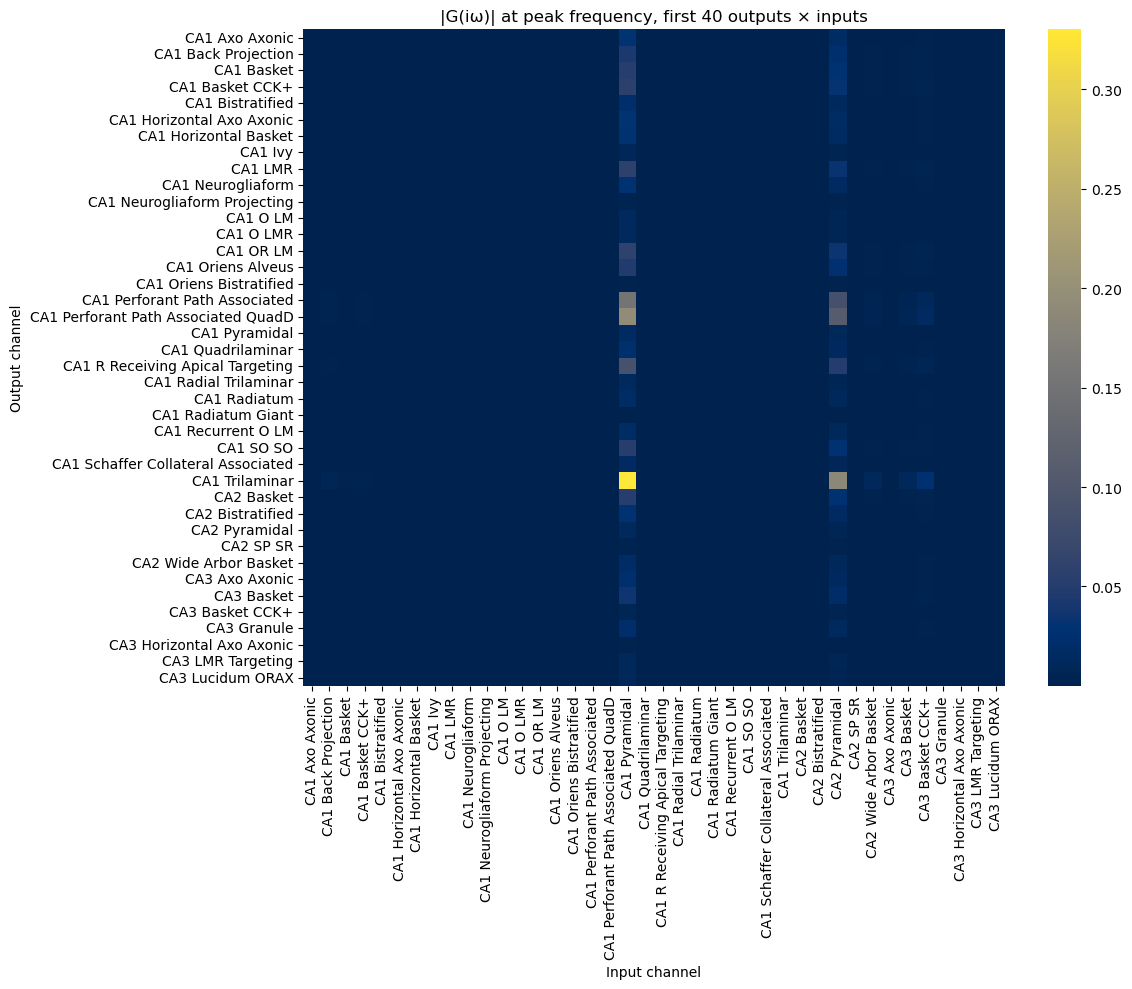

In [12]:
top_channels = nlt.top_frequency_channels(
    peak_G,
    input_labels=driver_labels,
    output_labels=output_labels,
    n=TOP_N_PRINT,
)

print("=" * 90)
print(f"TOP {TOP_N_PRINT} TRANSFER CHANNELS AT PEAK FREQUENCY")
print("=" * 90)
print(f"Peak omega: {peak_omega:.6g}")
display(top_channels[["input", "output", "magnitude", "phase_degrees", "value"]])

# Visualize a small top-left block if all-to-all is large.
max_show = min(40, peak_G.shape[0], peak_G.shape[1])
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    np.abs(peak_G[:max_show, :max_show]),
    xticklabels=driver_labels[:max_show],
    yticklabels=output_labels[:max_show],
    cmap="cividis",
    ax=ax,
)
ax.set_title(f"|G(iω)| at peak frequency, first {max_show} outputs × inputs")
ax.set_xlabel("Input channel")
ax.set_ylabel("Output channel")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Optional: Frequency Response at Selected Channels

Use this section to track specific input→output pairs across frequency.

Edit `CHANNELS_TO_TRACE` with labels or integer indices.

In [13]:
# Examples:
# CHANNELS_TO_TRACE = [
#     ("Some input label", "Some output label"),
#     (0, 0),
# ]
CHANNELS_TO_TRACE = []

label_to_driver_pos = {label: pos for pos, label in enumerate(driver_labels)}
label_to_output_pos = {label: pos for pos, label in enumerate(output_labels)}

if len(CHANNELS_TO_TRACE) == 0:
    print("No channels selected. Add pairs to CHANNELS_TO_TRACE to plot specific transfer entries.")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    for input_node, output_node in CHANNELS_TO_TRACE:
        in_pos = input_node if isinstance(input_node, int) else label_to_driver_pos[input_node]
        out_pos = output_node if isinstance(output_node, int) else label_to_output_pos[output_node]

        channel_gain = np.array([
            abs(G[out_pos, in_pos]) for G in freq_results["responses"]
        ])

        ax.loglog(
            omega,
            channel_gain,
            label=f"{driver_labels[in_pos]} → {output_labels[out_pos]}",
        )

    ax.set_title("Selected Transfer-Function Channels")
    ax.set_xlabel(r"Angular frequency $\omega$")
    ax.set_ylabel(r"$|G_{output,input}(i\omega)|$")
    ax.grid(True, which="both", linestyle=":")
    ax.legend()
    plt.tight_layout()
    plt.show()

No channels selected. Add pairs to CHANNELS_TO_TRACE to plot specific transfer entries.


# Final Interpretation Checklist

Use this checklist when reading the results:

1. **Matrix powers** answer: “Who reaches whom through paths of length \(k\)?”
2. **Cumulative path reachability** answers: “Who has the strongest total multi-step structural influence?”
3. **Discrete controllability Gramian** answers: “Which states can be energized over a finite number of update steps?”
4. **Continuous Gramian** answers: “Which states diffuse energy under a stable leakage model?”
5. **Frequency response** answers: “Which input-output channels are amplified at which frequencies?”

The notebook intentionally prints intermediate objects and top-ranked tables so you can audit every step.